# H1 피처 선택: 피처 조합 완전탐색 + Greedy

**목표:** `features_monthly.csv`의 모든 사용 가능 피처를 후보 풀로 놓고, 여러 피처 조합을 직접
계산·비교하여 주차 후보 분리에 **최적인 피처 집합**을 도출한다.

**탐색 전략 (두 방식 병행):**
1. **완전탐색 (exhaustive)** — 신호별 대표형 1종으로 큐레이션한 풀에서 크기 2~5의 모든 조합 평가
2. **Greedy forward** — 전체 풀(~22 피처)에서 1개씩 탐욕 추가 (선형 확장성, 대형 풀 대응)

**평가 기준 (silhouette + 검증 게이트):**
- **silhouette** (k=2~6 중 최고) — 클러스터 구조 품질 (1차 정렬 기준)
- **검증 게이트(`valid`)** — 성장 정체 클러스터가 *소수(1~50%)* & *park(stag≥4) enrich ≥ 1.5* & *recall ≥ 0.5*

> **silhouette 함정 보정:** silhouette 는 zero-inflated/저차원 피처셋에서 인위적으로 팽창한다
> 단독으로 silhouette 0.88. 이를 막기 위해 ① **near-constant 제거**(dom_frac>0.70) ②
> **비퇴화 게이트**(최대 클러스터 비중 ≤ 0.90) ③ **n_feat ≥ 3 권고**(다차원) 를 적용한다.

> 전처리는 `h1_clustering.ipynb` 셀1과 동일하게 재현 (eda/h1 수정 없음). 별도 실험 노트북.

In [1]:
import os, warnings, time, json
warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager
_font_path = "../assets/NanumSquareNeo-bRg.ttf"
font_manager.fontManager.addfont(_font_path)
_font_prop = font_manager.FontProperties(fname=_font_path)
matplotlib.rcParams["font.family"] = _font_prop.get_name()
matplotlib.rcParams["axes.unicode_minus"] = False
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42
UPPER_CLIP_Q = 0.99
CP_WINSOR_Q = (0.01, 0.99)

def qclip_nonnegative(s, upper_q=UPPER_CLIP_Q):
    s = pd.to_numeric(s, errors="coerce").clip(lower=0)
    upper = s.quantile(upper_q)
    return s.clip(upper=upper)

def winsor_quantile(s, lower_q=CP_WINSOR_Q[0], upper_q=CP_WINSOR_Q[1]):
    s = pd.to_numeric(s, errors="coerce")
    lower, upper = s.quantile([lower_q, upper_q])
    return s.clip(lower=lower, upper=upper)

def find_elbow_k(ks, inertias):
    # inertia ?? ?? ?(chord)?? ???? ??? k = elbow (?? [0,1] ???)
    x = np.array(ks, dtype=float); y = np.array(inertias, dtype=float)
    x = (x - x.min()) / (x.max() - x.min() + 1e-12)
    y = (y - y.min()) / (y.max() - y.min() + 1e-12)
    x0, y0, x1, y1 = x[0], y[0], x[-1], y[-1]
    num = np.abs((y1 - y0) * x - (x1 - x0) * y + x1 * y0 - y1 * x0)
    den = np.hypot(y1 - y0, x1 - x0) + 1e-12
    return ks[int(np.argmax(num / den))]

# ?? ??? ?? (h1_clustering.ipynb ?1 ??) ???????????????????????????????
df_raw = pd.read_csv("../data/features_monthly.csv", encoding="utf-8-sig")
mc = pd.read_csv("../data/main_characters.csv", encoding="utf-8-sig",
                 usecols=["ocid", "class_group"])
df = df_raw.merge(mc, on="ocid", how="left")
hf = pd.read_csv("../data/hexa_fragments.csv", encoding="utf-8-sig",
                 usecols=["ocid", "avg_monthly_delta_hexa_frag",
                          "recent3_delta_hexa_frag", "recent6_delta_hexa_frag"])
df = df.merge(hf, on="ocid", how="left")

df = df[df["level"].between(270, 290)].copy()
df["level_bin"] = pd.cut(df["level"], bins=[269, 279, 285, 290],
                         labels=["270-279", "280-285", "286-290"])

_core = ["avg_monthly_delta_level", "avg_monthly_delta_combat_power",
         "avg_monthly_delta_union_level"]
df = df.dropna(subset=_core).copy()
df["union_level"] = df["union_level"].fillna(0)
df["delta_cp_winsor"] = winsor_quantile(df["avg_monthly_delta_combat_power"])
df["delta_union_clip"] = qclip_nonnegative(df["avg_monthly_delta_union_level"])
df["delta_auth_clip"] = qclip_nonnegative(df["avg_monthly_delta_authentic_symbol"])
df["delta_level_clip"] = qclip_nonnegative(df["avg_monthly_delta_level"])
df_final = df.reset_index(drop=True)

_stag = ["delta_level_clip", "delta_cp_winsor", "delta_union_clip", "delta_auth_clip"]
df_final["stagnation_score"] = (
    sum((df_final[c] <= df_final[c].quantile(0.25)).astype(int) for c in _stag)
)

BAND_LABELS = ["270-279", "280-285", "286-290"]
BAND_PALETTE = {"270-279": "#4e79a7", "280-285": "#f28e2b", "286-290": "#e15759"}
print(f"df_final: {len(df_final):,}?  |  ?? {df_final.shape[1]}?")
print(f"clip policy: nonnegative deltas upper p{int(UPPER_CLIP_Q*100)}, combat_power p01-p99")

df_final: 1,979?  |  ?? 54?
clip policy: nonnegative deltas upper p99, combat_power p01-p99


## ?? ?? ? ??

`features_monthly.csv` + `hexa_fragments.csv`? ????? ??? ?? ?? ???
**?? ??(????log1p?winsorize)? ??**?? NaN? ??, ?? ??? **??? n**??
????? ?? (??? dropna ?? ?? ? silhouette ?? ???).

- recent3/6 ??? NaN(?? ??)? 12mo avg ????? fallback
- cumEXP? ?? `log1p`??? ?? winsorize ?? ??
- union / authentic / hexa / hfrag / level delta? lower 0 + upper p99 clipping
- combat_power ??? ?? ??? ???? p01~p99 winsorizing


In [2]:
# ?? ?? ?? ? (??? ?? ??, NaN ??) ????????????????????????????????
F = pd.DataFrame(index=df_final.index)

# (1) cumEXP ? level-invariant ?? ?? (?? log1p)
F["cumexp_avg"] = df_final["log1p_avg_monthly_delta_cumexp"].fillna(0)
F["cumexp_r3"]  = df_final["log1p_recent3_delta_cumexp"].fillna(df_final["log1p_avg_monthly_delta_cumexp"]).fillna(0)
F["cumexp_r6"]  = df_final["log1p_recent6_delta_cumexp"].fillna(df_final["log1p_avg_monthly_delta_cumexp"]).fillna(0)

# (2) ??? ? p01~p99 winsorized forms
F["cp_avg"]     = winsor_quantile(df_final["avg_monthly_delta_combat_power"])
F["cp_winsor"]  = df_final["delta_cp_winsor"]
F["cp_r3"]      = winsor_quantile(df_final["recent3_delta_combat_power"].fillna(df_final["avg_monthly_delta_combat_power"]))
F["cp_r6"]      = winsor_quantile(df_final["recent6_delta_combat_power"].fillna(df_final["avg_monthly_delta_combat_power"]))

# (3) ??? ?? ? lower 0 + upper p99
F["union_avg"]  = qclip_nonnegative(df_final["avg_monthly_delta_union_level"])
F["union_r3"]   = qclip_nonnegative(df_final["recent3_delta_union_level"].fillna(df_final["avg_monthly_delta_union_level"]))
F["union_r6"]   = qclip_nonnegative(df_final["recent6_delta_union_level"].fillna(df_final["avg_monthly_delta_union_level"]))

# (4) ??? ?? ? lower 0 + upper p99
F["auth_avg"]   = qclip_nonnegative(df_final["avg_monthly_delta_authentic_symbol"])
F["auth_r3"]    = qclip_nonnegative(df_final["recent3_delta_authentic_symbol"].fillna(df_final["avg_monthly_delta_authentic_symbol"]))
F["auth_r6"]    = qclip_nonnegative(df_final["recent6_delta_authentic_symbol"].fillna(df_final["avg_monthly_delta_authentic_symbol"]))

# (6) ?? ?? ? lower 0 + upper p99
F["hexa_avg"]   = qclip_nonnegative(df_final["avg_monthly_delta_hexa"])
F["hexa_r3"]    = qclip_nonnegative(df_final["recent3_delta_hexa"].fillna(df_final["avg_monthly_delta_hexa"]))

# (7) ?? ?? ?? ? lower 0 + upper p99
F["hfrag_avg"]  = qclip_nonnegative(df_final["avg_monthly_delta_hexa_frag"]).fillna(0)
F["hfrag_r3"]   = qclip_nonnegative(df_final["recent3_delta_hexa_frag"].fillna(df_final["avg_monthly_delta_hexa_frag"])).fillna(0)
F["hfrag_r6"]   = qclip_nonnegative(df_final["recent6_delta_hexa_frag"].fillna(df_final["avg_monthly_delta_hexa_frag"])).fillna(0)

# (8) ?? delta (??? ?? baseline ? ???) ? lower 0 + upper p99
F["level_avg"]  = qclip_nonnegative(df_final["avg_monthly_delta_level"])

# (9) ?? ??
F["access_ratio"]  = df_final["access_ratio"].fillna(0)
F["access_months"] = df_final["access_active_months"].fillna(0)

assert F.isna().sum().sum() == 0, "F ? NaN ??"
print(f"?? ?? ?(??): {F.shape[1]}?")

# ?? near-constant ?? ?? (??? ??? dom_frac > 0.70) ???????????????????
# ? ?(?? 0)? 70%+ ? StandardScaler ? ???? ?? blob ? silhouette ?? ??.
dom = {c: F[c].round(6).value_counts(normalize=True).iloc[0] for c in F.columns}
DROP_NC = [c for c, v in dom.items() if v > 0.70]
print("near-constant ?? (dom_frac>0.70):", {c: round(dom[c], 3) for c in DROP_NC})
F = F.drop(columns=DROP_NC)
FULL_POOL = list(F.columns)
print(f"?? ?? ?(?? ?): {len(FULL_POOL)}?")
print(FULL_POOL)

# ?? ?? ?? ?? ?? (?? ??? ?? ? ?? ????) ?????????????????????????
# ?level<=0.1 ?? proxy ? lv270-290 ?? ??? ? ??? ??? ???(???).
park         = (df_final["stagnation_score"] >= 4)
stag4        = (df_final["stagnation_score"] == 4)
parked_proxy = (df_final["delta_level_clip"] <= 0.1)
print(f"\npark(stag>=4): {park.mean():.1%} (n={int(park.sum())})  |  "
      f"stag4: {int(stag4.sum())}  |  parked_proxy(?lv<=0.1): {parked_proxy.mean():.1%}")

# ?? ?? ??? + ??? (??? ??? ????) ?????????????????????????????
# ?? ??? ??? ??(cumexp_avg/r3/r6)? collinear ? '???'? ?? 1D ??.
# ??? = ?? prefix(cumexp/cp/union/auth/hexa/hfrag/level/access). ???? ???? 1?.
FAMILY = {c: c.split("_")[0] for c in F.columns}
CORR = F.corr().abs()
def max_pair_corr(cols):
    cols = list(cols)
    if len(cols) < 2:
        return 0.0
    sub = CORR.loc[cols, cols].values
    return float(np.max(sub[np.triu_indices(len(cols), k=1)]))
print("???:", sorted(set(FAMILY.values())))

?? ?? ?(??): 21?
near-constant ?? (dom_frac>0.70): {'access_months': 0.717}
?? ?? ?(?? ?): 20?
['cumexp_avg', 'cumexp_r3', 'cumexp_r6', 'cp_avg', 'cp_winsor', 'cp_r3', 'cp_r6', 'union_avg', 'union_r3', 'union_r6', 'auth_avg', 'auth_r3', 'auth_r6', 'hexa_avg', 'hexa_r3', 'hfrag_avg', 'hfrag_r3', 'hfrag_r6', 'level_avg', 'access_ratio']

park(stag>=4): 5.8% (n=114)  |  stag4: 114  |  parked_proxy(?lv<=0.1): 15.0%
???: ['access', 'auth', 'cp', 'cumexp', 'hexa', 'hfrag', 'level', 'union']


## 평가 함수

조합 1개 → StandardScale → KMeans(k=2~6) → 최고 silhouette. 성장 정체 클러스터는
**외부 기준** `park`(stag≥4) 비율이 최대인 클러스터로 식별 (선택 피처와 독립 → 순환논리 방지).
`valid` = size∈[1%,50%] & enrich≥1.5 & recall≥0.5 & 최대클러스터비중≤0.90 & 최소비중≥0.02.

In [3]:
# ── 피처 조합 평가 함수 ───────────────────────────────────────────────────────
SEARCH_KS   = list(range(2, 7))   # k=2~6
N_INIT_SRCH = 4                   # 탐색 속도용 (최종 refit 은 n_init=20)
SIL_SAMPLE  = 1200                # silhouette 표본 (n>1200 시 부분표본 → 속도)

def _best_km(Xs, ks, n_init, sample):
    best_s, best_k, best_lbl = -1.0, None, None
    for k in ks:
        lbl = KMeans(n_clusters=k, n_init=n_init, random_state=RANDOM_STATE).fit_predict(Xs)
        if sample and len(Xs) > sample:
            s = silhouette_score(Xs, lbl, sample_size=sample, random_state=RANDOM_STATE)
        else:
            s = silhouette_score(Xs, lbl)
        if s > best_s:
            best_s, best_k, best_lbl = s, k, lbl
    return best_s, best_k, best_lbl

def eval_set(cols, ks=SEARCH_KS, n_init=N_INIT_SRCH, sample=SIL_SAMPLE):
    Xs = StandardScaler().fit_transform(F[list(cols)].values)
    sil, k, lbl = _best_km(Xs, ks, n_init, sample)
    s = pd.Series(lbl, index=F.index)
    fr = s.value_counts(normalize=True)
    max_frac, min_frac = float(fr.max()), float(fr.min())
    pc = park.groupby(s).mean().idxmax()          # 성장 정체 클러스터 = park(stag>=4) 비율 최대
    mask = (s == pc).values
    size = mask.mean()
    enrich = park.values[mask].mean() / max(park.mean(), 1e-9)
    recall = park.values[mask].sum() / max(park.sum(), 1)
    # 비퇴화 게이트: 거대 단일 blob(>0.90) / 미세 singleton(<0.02) 클러스터 배제
    valid = ((0.01 <= size <= 0.50) and (enrich >= 1.5) and (recall >= 0.5)
             and (max_frac <= 0.90) and (min_frac >= 0.02))
    nfam = len(set(FAMILY[c] for c in cols))
    return {"sil": round(float(sil), 4), "k": int(k), "n_feat": len(cols),
            "n_fam": nfam, "maxcorr": round(max_pair_corr(cols), 2),
            "size%": round(size * 100, 1), "enrich": round(float(enrich), 2),
            "recall": round(float(recall), 3), "maxfrac": round(max_frac, 2),
            "valid": bool(valid)}

# smoke test — 현행 Set A(v3) 평가
SET_A_V3 = ["cumexp_avg", "cp_avg", "union_avg", "auth_avg", "hfrag_avg"]
print("현행 Set A(v3):", eval_set(SET_A_V3))

현행 Set A(v3): {'sil': 0.4761, 'k': 4, 'n_feat': 5, 'n_fam': 5, 'maxcorr': 0.59, 'size%': 1.8, 'enrich': 5.79, 'recall': 0.105, 'maxfrac': 0.74, 'valid': False}


## 완전탐색 — 큐레이션 풀 (크기 2~5)

신호별 대표형 1종(주로 12mo avg + cumEXP + access)으로 11개 풀 구성 →
`C(11,2..5)=1,012` 조합 전수 평가. 조합 폭발 방지를 위해 redundant 형태(winsor/recent 중복)는
완전탐색 풀에서 제외하고 greedy 단계에서 전체 풀로 확장.

In [4]:
# ── 완전탐색 ──────────────────────────────────────────────────────────────────
_cur = ["cumexp_avg", "cp_avg", "union_avg", "auth_avg", "hexa_avg", "hfrag_avg",
        "level_avg", "access_ratio", "access_months", "cumexp_r3", "cumexp_r6"]
CURATED = [c for c in _cur if c in FULL_POOL]
print(f"큐레이션 풀 {len(CURATED)}개: {CURATED}")

rows, t0 = [], time.time()
for r in range(2, 6):
    for combo in combinations(CURATED, r):
        res = eval_set(combo); res["features"] = combo
        rows.append(res)
exh = pd.DataFrame(rows)
print(f"평가 조합 {len(exh)}개  |  {time.time() - t0:.1f}s")

exh_valid = exh[exh["valid"]].sort_values("sil", ascending=False).reset_index(drop=True)
print(f"\nvalid 조합: {len(exh_valid)} / {len(exh)}")
print("\n── valid 조합 silhouette 상위 15 (corr 높음 = 같은 신호 중복) ──")
for _, r in exh_valid.head(15).iterrows():
    print(f"  sil={r['sil']:.4f} k={r['k']} nf={r['n_feat']} fam={r['n_fam']} "
          f"corr={r['maxcorr']:.2f} size={r['size%']:>4}% recall={r['recall']:.2f}  {list(r['features'])}")

print("\n── (참고) valid 무시 silhouette 순수 상위 8 — 저차원 zero-gap 과대평가 확인용 ──")
for _, r in exh.sort_values("sil", ascending=False).head(8).iterrows():
    v = "valid" if r["valid"] else "INVALID"
    print(f"  sil={r['sil']:.4f} k={r['k']} nf={r['n_feat']} size={r['size%']:>4}% "
          f"maxfrac={r['maxfrac']} [{v}]  {list(r['features'])}")

큐레이션 풀 10개: ['cumexp_avg', 'cp_avg', 'union_avg', 'auth_avg', 'hexa_avg', 'hfrag_avg', 'level_avg', 'access_ratio', 'cumexp_r3', 'cumexp_r6']


평가 조합 627개  |  150.7s

valid 조합: 208 / 627

── valid 조합 silhouette 상위 15 (corr 높음 = 같은 신호 중복) ──
  sil=0.6819 k=2 nf=4 fam=2 corr=0.72 size=11.5% recall=0.51  ['cumexp_avg', 'access_ratio', 'cumexp_r3', 'cumexp_r6']
  sil=0.6805 k=2 nf=3 fam=2 corr=0.72 size=11.4% recall=0.52  ['cp_avg', 'cumexp_r3', 'cumexp_r6']
  sil=0.6680 k=2 nf=2 fam=2 corr=0.48 size=16.5% recall=0.54  ['access_ratio', 'cumexp_r6']
  sil=0.6680 k=2 nf=3 fam=2 corr=0.50 size=12.8% recall=0.54  ['cumexp_avg', 'access_ratio', 'cumexp_r3']
  sil=0.6583 k=2 nf=4 fam=2 corr=0.72 size=11.8% recall=0.53  ['cumexp_avg', 'cp_avg', 'cumexp_r3', 'cumexp_r6']
  sil=0.6570 k=2 nf=4 fam=2 corr=0.72 size=12.0% recall=0.53  ['cumexp_avg', 'level_avg', 'cumexp_r3', 'cumexp_r6']
  sil=0.6497 k=2 nf=3 fam=2 corr=0.50 size=11.0% recall=0.50  ['cumexp_avg', 'hfrag_avg', 'cumexp_r3']
  sil=0.6468 k=2 nf=3 fam=2 corr=0.50 size=11.6% recall=0.54  ['cumexp_avg', 'cp_avg', 'cumexp_r3']
  sil=0.6463 k=2 nf=4 fam=2 corr=0.72 size=11.7% recall

## Greedy forward selection — 전체 풀

전체 22개 풀에서 1개씩 탐욕 추가. 매 단계 `(valid, silhouette)` 사전식 최대 피처 채택
(valid 우선 → 동률 시 silhouette). 완전탐색이 불가능한 대형 풀에서도 선형 비용으로 확장.

In [5]:
# ── Greedy forward selection ──────────────────────────────────────────────────
def greedy_forward(pool, max_feat=6):
    chosen, path, remaining = [], [], list(pool)
    while remaining and len(chosen) < max_feat:
        best = None
        for f in remaining:
            res = eval_set(chosen + [f])
            key = (res["valid"], res["sil"])
            if best is None or key > best[0]:
                best = (key, f, res)
        _, f, res = best
        chosen.append(f); remaining.remove(f)
        path.append({**res, "added": f, "set": tuple(chosen)})
    return pd.DataFrame(path)

t0 = time.time()
gpath = greedy_forward(FULL_POOL, max_feat=6)
print(f"greedy 경로 ({time.time() - t0:.1f}s):")
for _, r in gpath.iterrows():
    flag = "v" if r["valid"] else " "
    print(f"  +{r['added']:13s} -> n={r['n_feat']} sil={r['sil']:.4f} k={r['k']} "
          f"size={r['size%']:>4}% enrich={r['enrich']:>4} recall={r['recall']:.2f} valid[{flag}]")

greedy 경로 (22.2s):
  +access_ratio  -> n=1 sil=0.7268 k=2 size=24.2% enrich=2.39 recall=0.58 valid[v]
  +cumexp_r6     -> n=2 sil=0.6680 k=2 size=16.5% enrich=3.25 recall=0.54 valid[v]
  +union_r6      -> n=3 sil=0.6011 k=3 size=14.9% enrich=3.59 recall=0.54 valid[v]
  +level_avg     -> n=4 sil=0.5159 k=3 size=11.6% enrich=4.45 recall=0.52 valid[v]
  +cumexp_avg    -> n=5 sil=0.5346 k=2 size=10.2% enrich=5.16 recall=0.53 valid[v]
  +cumexp_r3     -> n=6 sil=0.5565 k=2 size=11.3% enrich=4.57 recall=0.52 valid[v]


## 최적(추천) 피처셋 선택 + 최종 클러스터 프로파일

광역 탐색의 silhouette 1위는 `cumexp_avg/r3/r6`처럼 **같은 신호의 시계열 복제**(corr≈1)로,
다차원이 아니라 1D를 부풀린 것 → 기각. 추천셋은 **패밀리당 1개 + pairwise |corr|<0.85**로
서로 다른 성장축을 강제해 선정한다 (canonical 12mo form 기준). 이후 `n_init=20` full
silhouette refit → 프로파일 / 레벨밴드·계열 분포 → `optimal_feature_set.json` 저장.

In [6]:
# ── 추천셋 탐색: 패밀리당 1개(canonical 12mo) + 저공선성 → 다신호 다양성 확보 ──
# 광역 탐색 1위(cumexp×3)는 collinear 1D 복제 → 기각. 추천셋은 서로 다른 성장축으로 구성.
REP = [c for c in ["cumexp_avg", "cp_avg", "union_avg", "auth_avg", "hexa_avg",
                   "hfrag_avg", "level_avg", "access_ratio"] if c in FULL_POOL]
print(f"패밀리 대표 풀 {len(REP)}개: {REP}")

rec_rows = []
for r in range(3, 6):
    for combo in combinations(REP, r):
        res = eval_set(combo)
        if res["valid"] and res["maxcorr"] < 0.85:
            res["features"] = combo; rec_rows.append(res)
rec = pd.DataFrame(rec_rows).sort_values("sil", ascending=False).reset_index(drop=True)
print(f"\n추천 후보(valid & corr<0.85 & 패밀리 1개씩) {len(rec)}개 — 상위 10:")
for _, r in rec.head(10).iterrows():
    print(f"  sil={r['sil']:.4f} k={r['k']} nf={r['n_feat']} corr={r['maxcorr']:.2f} "
          f"size={r['size%']:>4}% enrich={r['enrich']:>4} recall={r['recall']:.2f}  {list(r['features'])}")

if len(rec):
    OPT_FEATURES, OPT_SRC, best_sil_search = list(rec.iloc[0]["features"]), "family-diverse", float(rec.iloc[0]["sil"])
else:   # fallback (이론상 도달 안 함): 광역 valid n_feat>=3
    r = exh_valid[exh_valid["n_feat"] >= 3].iloc[0]
    OPT_FEATURES, OPT_SRC, best_sil_search = list(r["features"]), "exhaustive", float(r["sil"])
print(f"\n채택(추천셋): {OPT_FEATURES}  source={OPT_SRC}  search_sil={best_sil_search:.4f}")

# ── 최종 refit: h1_clustering.ipynb 기준 통일 (원본 컬럼 dropna + cumEXP idxmin) ──
# 탐색은 공정비교 위해 F(fillna) 사용. 최종 채택셋은 h1_clustering.ipynb 와 동일하게
# ?? refit? h1_clustering.ipynb? ?? ???? ??? optimal_feature_set.json? RESULT.md? ??? ???.
df_final["delta_union"] = qclip_nonnegative(df_final["avg_monthly_delta_union_level"])
df_final["delta_hfrag"] = qclip_nonnegative(df_final["avg_monthly_delta_hexa_frag"]).fillna(0)
H1_COLMAP = {"cumexp_avg": "log1p_avg_monthly_delta_cumexp",
             "union_avg": "delta_union", "hfrag_avg": "delta_hfrag"}
opt_cols = [H1_COLMAP.get(c, c) for c in OPT_FEATURES]
X_opt = df_final[opt_cols].dropna()
idx_opt = X_opt.index
Xo = StandardScaler().fit_transform(X_opt.values)

ks_o, inert, sils = list(range(2, 9)), [], []
for k in ks_o:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(Xo)
    inert.append(km.inertia_); sils.append(silhouette_score(Xo, km.labels_))
elbow_o = find_elbow_k(ks_o, inert)
bestk_o = ks_o[int(np.argmax(sils))]
FINAL_K = bestk_o
km_o = KMeans(n_clusters=FINAL_K, n_init=20, random_state=RANDOM_STATE).fit(Xo)
df_final["fs_cluster"] = pd.Series(pd.NA, index=df_final.index, dtype="Int64")
df_final.loc[idx_opt, "fs_cluster"] = km_o.labels_

# 성장 정체 클러스터 = cumEXP 성장 최소 (h1_clustering.ipynb 동일 규칙)
g = df_final.loc[idx_opt].groupby("fs_cluster")
prof = g[opt_cols].mean()
prof["n"] = g.size()
prof["park%"]   = g.apply(lambda x: park.loc[x.index].mean() * 100)
prof["stag4%"]  = g.apply(lambda x: stag4.loc[x.index].mean() * 100)
prof["Δlv≤.1%"] = g.apply(lambda x: parked_proxy.loc[x.index].mean() * 100)
stagnant_id = int(prof[opt_cols[0]].idxmin())
prof["is_stagnant_cluster"] = (prof.index == stagnant_id).astype(int)

print(f"\nelbow k={elbow_o}  best-sil k={bestk_o}  -> FINAL_K={FINAL_K}, sil={max(sils):.4f}")
print(f"성장 정체 클러스터 ID={stagnant_id}\n")
display(prof.round(3).T)

print("\n레벨 밴드 분포 (행 비율 %):")
display((pd.crosstab(df_final.loc[idx_opt, "fs_cluster"], df_final.loc[idx_opt, "level_bin"],
                     normalize="index") * 100).round(1))
if "class_group" in df_final.columns:
    print("\n계열 분포 (행 비율 %):")
    display((pd.crosstab(df_final.loc[idx_opt, "fs_cluster"], df_final.loc[idx_opt, "class_group"],
                         normalize="index") * 100).round(1))

# ── 저장 (성장 정체 비율 분모 = 분석 표본 df_final → h1 과 동일) ──────────────
is_park_opt = (df_final.loc[idx_opt, "fs_cluster"] == stagnant_id)
n_stag = int(is_park_opt.sum())
opt = {"features": OPT_FEATURES, "k": int(FINAL_K),
       "silhouette": round(float(max(sils)), 4), "elbow_k": int(elbow_o),
       "stagnant_cluster_id": stagnant_id, "source": OPT_SRC,
       "stagnant_n": n_stag, "stagnant_size_pct": round(n_stag / len(df_final) * 100, 1)}
with open("optimal_feature_set.json", "w", encoding="utf-8") as fp:
    json.dump(opt, fp, ensure_ascii=False, indent=2)
print("\noptimal_feature_set.json 저장:")
print(json.dumps(opt, ensure_ascii=False, indent=2))

패밀리 대표 풀 8개: ['cumexp_avg', 'cp_avg', 'union_avg', 'auth_avg', 'hexa_avg', 'hfrag_avg', 'level_avg', 'access_ratio']



추천 후보(valid & corr<0.85 & 패밀리 1개씩) 31개 — 상위 10:
  sil=0.5463 k=3 nf=3 corr=0.45 size=20.8% enrich=2.99 recall=0.62  ['cumexp_avg', 'union_avg', 'access_ratio']
  sil=0.5071 k=3 nf=3 corr=0.45 size=20.3% enrich=3.11 recall=0.63  ['cumexp_avg', 'level_avg', 'access_ratio']
  sil=0.4960 k=4 nf=3 corr=0.32 size=22.3% enrich=2.59 recall=0.58  ['union_avg', 'hfrag_avg', 'access_ratio']
  sil=0.4546 k=4 nf=3 corr=0.32 size=22.2% enrich=2.68 recall=0.60  ['hfrag_avg', 'level_avg', 'access_ratio']
  sil=0.4494 k=4 nf=3 corr=0.36 size=21.9% enrich= 2.6 recall=0.57  ['union_avg', 'hexa_avg', 'access_ratio']
  sil=0.4485 k=5 nf=3 corr=0.30 size=21.9% enrich=2.65 recall=0.58  ['union_avg', 'auth_avg', 'access_ratio']
  sil=0.4464 k=4 nf=4 corr=0.45 size=18.6% enrich= 3.1 recall=0.58  ['cumexp_avg', 'union_avg', 'hfrag_avg', 'access_ratio']
  sil=0.4433 k=2 nf=3 corr=0.45 size=25.8% enrich=2.75 recall=0.71  ['cumexp_avg', 'cp_avg', 'access_ratio']
  sil=0.4301 k=3 nf=3 corr=0.59 size=22.9% enrich=2


elbow k=4  best-sil k=3  -> FINAL_K=3, sil=0.5446
성장 정체 클러스터 ID=1



fs_cluster,0,1,2
log1p_avg_monthly_delta_cumexp,30.140,27.028,29.983
delta_union,39.087,38.341,337.108
access_ratio,0.934,0.484,0.877
n,1419.000,412.000,148.000
park%,3.030,17.233,0.000
stag4%,3.030,17.233,0.000
Δlv≤.1%,8.316,42.233,3.378
is_stagnant_cluster,0.000,1.000,0.000



레벨 밴드 분포 (행 비율 %):


level_bin,270-279,280-285,286-290
fs_cluster,,,
0,24.7,36.8,38.5
1,67.2,28.6,4.1
2,41.9,31.8,26.4



계열 분포 (행 비율 %):


class_group,궁수,도적,마법사,전사,해적
fs_cluster,,,,,
0,19.5,20.4,21.1,19.3,19.7
1,21.4,19.9,17.7,20.6,20.4
2,23.0,18.9,14.9,24.3,18.9



optimal_feature_set.json 저장:
{
  "features": [
    "cumexp_avg",
    "union_avg",
    "access_ratio"
  ],
  "k": 3,
  "silhouette": 0.5446,
  "elbow_k": 4,
  "stagnant_cluster_id": 1,
  "source": "family-diverse",
  "stagnant_n": 412,
  "stagnant_size_pct": 20.8
}


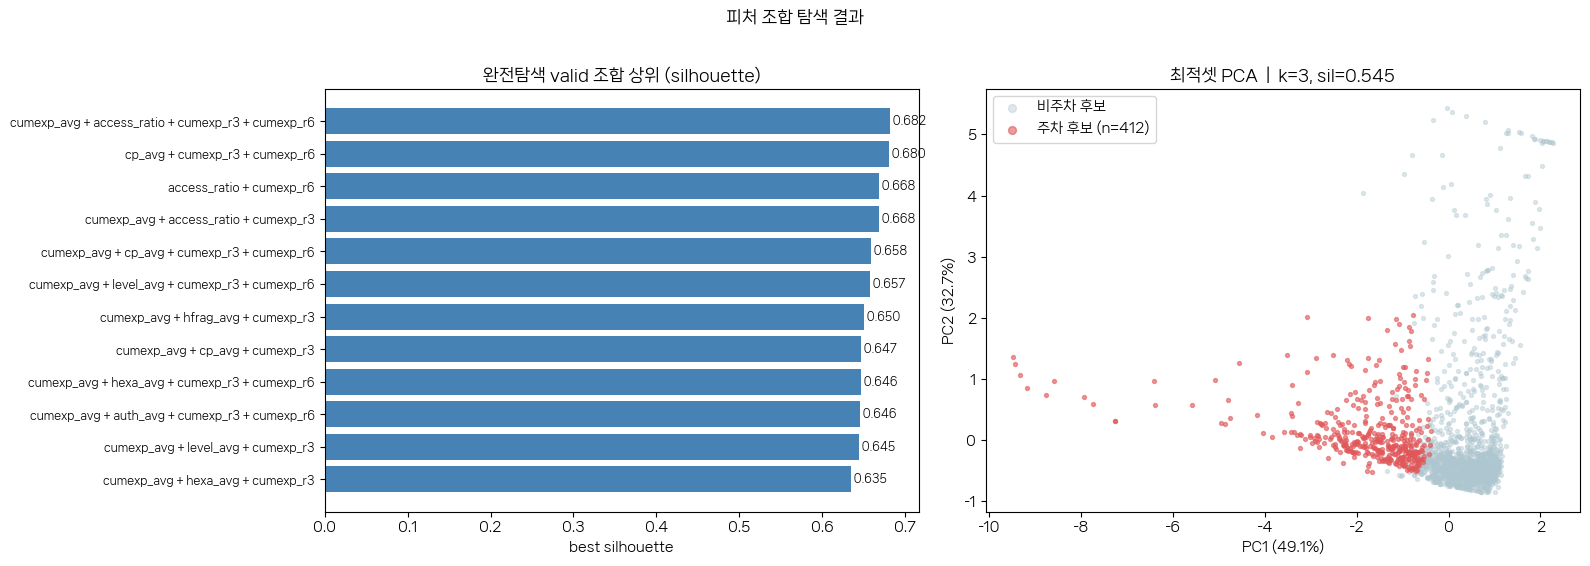

In [7]:
# ── 시각화: 탐색 상위 조합 + 최적셋 PCA ──────────────────────────────────────
fig, (axL, axR) = plt.subplots(1, 2, figsize=(16, 5.5))

topN = (exh_valid.head(12).iloc[::-1] if len(exh_valid)
        else exh.sort_values("sil").tail(12))
labels = [" + ".join(f) for f in topN["features"]]
axL.barh(range(len(topN)), topN["sil"], color="steelblue")
axL.set_yticks(range(len(topN))); axL.set_yticklabels(labels, fontsize=8)
axL.set_xlabel("best silhouette"); axL.set_title("완전탐색 valid 조합 상위 (silhouette)")
for i, v in enumerate(topN["sil"]):
    axL.text(v, i, f" {v:.3f}", va="center", fontsize=8)

ispk = (df_final.loc[idx_opt, "fs_cluster"] == stagnant_id).values
pca = PCA(n_components=2, random_state=RANDOM_STATE)
P = pca.fit_transform(Xo)
axR.scatter(P[~ispk, 0], P[~ispk, 1], s=8, alpha=0.4, color="#aec6cf", label="비주차 후보")
axR.scatter(P[ispk, 0],  P[ispk, 1],  s=8, alpha=0.6, color="#e15759",
            label=f"주차 후보 (n={int(ispk.sum())})")
ev = pca.explained_variance_ratio_
axR.set_xlabel(f"PC1 ({ev[0]:.1%})"); axR.set_ylabel(f"PC2 ({ev[1]:.1%})")
axR.set_title(f"최적셋 PCA  |  k={FINAL_K}, sil={max(sils):.3f}")
axR.legend(markerscale=2)

plt.suptitle("피처 조합 탐색 결과", y=1.02)
plt.tight_layout()
plt.savefig("figures/13_feature_search.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# ── 요약 ──────────────────────────────────────────────────────────────────────
print("=" * 64)
print("  피처 선택 실험 요약")
print("=" * 64)
res_A = eval_set(SET_A_V3)
print(f"  현행 Set A(v3) : {SET_A_V3}")
print(f"    -> sil={res_A['sil']:.4f} k={res_A['k']} size={res_A['size%']}% "
      f"enrich={res_A['enrich']} recall={res_A['recall']} valid={res_A['valid']}")
print(f"  탐색 최적셋     : {OPT_FEATURES}  (source={OPT_SRC}, n_feat={len(OPT_FEATURES)})")
print(f"    -> sil={max(sils):.4f} k={FINAL_K} 주차 후보 {n_stag}명 ({n_stag / len(df_final):.1%})")
print()
delta = max(sils) - res_A["sil"]
verdict = "탐색셋이 Set A 대비 개선" if delta > 0.01 else (
          "Set A 와 동등" if abs(delta) <= 0.01 else "Set A 가 우위 (탐색셋 미채택 권고)")
print(f"  silhouette Δ(탐색-A) = {delta:+.4f}  ->  {verdict}")
print()
print("  [주의] silhouette 는 zero-inflated/저차원 피처셋에서 과대평가됨")
print("    (동일-0 점들이 dense blob → 인위적 gap). 보정 적용:")
print("    ① near-constant(dom_frac>0.70) 제거  ② 비퇴화 게이트(maxfrac<=0.9)")
print("    ③ n_feat>=3 권고  ④ 외부 park=stag>=4 enrich/recall 게이트")

  피처 선택 실험 요약


  현행 Set A(v3) : ['cumexp_avg', 'cp_avg', 'union_avg', 'auth_avg', 'hfrag_avg']
    -> sil=0.4761 k=4 size=1.8% enrich=5.79 recall=0.105 valid=False
  탐색 최적셋     : ['cumexp_avg', 'union_avg', 'access_ratio']  (source=family-diverse, n_feat=3)
    -> sil=0.5446 k=3 주차 후보 412명 (20.8%)

  silhouette Δ(탐색-A) = +0.0685  ->  탐색셋이 Set A 대비 개선

  [주의] silhouette 는 zero-inflated/저차원 피처셋에서 과대평가됨
    (동일-0 점들이 dense blob → 인위적 gap). 보정 적용:
    ① near-constant(dom_frac>0.70) 제거  ② 비퇴화 게이트(maxfrac<=0.9)
    ③ n_feat>=3 권고  ④ 외부 park=stag>=4 enrich/recall 게이트
